In [6]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz1_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz1"
NOBJ = 5
K = 5
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz1_front_random(NOBJ, 1000)

In [7]:
MU = 1000
NGEN = 600
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [8]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz1, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

c:\Users\luise\AppData\Local\Programs\Python\Python312\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\luise\AppData\Local\Programs\Python\Python312\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [9]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        pop_comp = pop[:(int)(MU/(1 << NOBJ))]
        hv_val = hypervolume(pop_comp, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        approx_front_comp = approx_front[:(int)(MU/(1 << NOBJ))]
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front_comp)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [10]:
pop, logbook = main()

gen	evals	std                                                          	min                                                     	avg                                                               	max                                                               	hypervolume	igd_plus
0  	1000 	[28.32935627 28.24047571 44.35953998 65.62005057 95.9805    ]	[0.00130642 0.00174293 0.0035968  0.00404329 0.33821203]	[ 17.2013622   17.3309491   33.43039884  65.57884053 140.65165865]	[237.01177534 251.79717955 362.04314322 400.42162631 444.83403448]	           	        
1  	1000 	[30.75920825 32.4435835  53.45009586 68.78479517 84.99436653]	[0.0010298  0.00156274 0.0035968  0.00404329 0.11880377]	[ 17.04384268  16.46819964  35.55172136  65.5458017  101.65854899]	[254.35661828 255.99406124 362.04314322 367.70414671 439.77531253]	0          	49.7945 
2  	1000 	[38.39684905 31.8027074  56.57271195 66.944786   71.70492465]	[4.03982246e-05 6.32779337e-04 2.28982076e-03 4.04328793e-03
 1.18803770e-01

[0.48516552846628624, 0.9251104100062304, 0.9047125245067222, 0.5842344012459235, 0.49999202599004067, 0.5000016037166798, 0.4999570660580728, 0.5000267276637904, 0.49998827865459883]
[0.6450034344533555, 0.8217088466661443, 0.9095429112658195, 0.3573857343317106, 0.4999695248014762, 0.4999583754404361, 0.4999738160535045, 0.5000018669205575, 0.4999408539002843]
[0.8366946882478882, 0.9394903339100684, 0.992176047168364, 0.4083460613268189, 0.4999868477977328, 0.49996605434731206, 0.4999474668172664, 0.5000093369647619, 0.49993613263567716]
[0.7620798235700725, 0.920828886717509, 0.4723980666465777, 0.7317276240444385, 0.49990927263152535, 0.4999739444437727, 0.4999284606521739, 0.4999704357547802, 0.4999472396714756]
[0.9885283675530886, 0.4202675191209637, 0.5614191385817151, 0.01423314536372015, 0.4999682982593419, 0.49999554114627465, 0.49995734385260426, 0.5000257976727479, 0.4999796649966633]
[0.7347976067337575, 0.36554594452830136, 0.7717414049576622, 0.9956517670328078, 0.4998

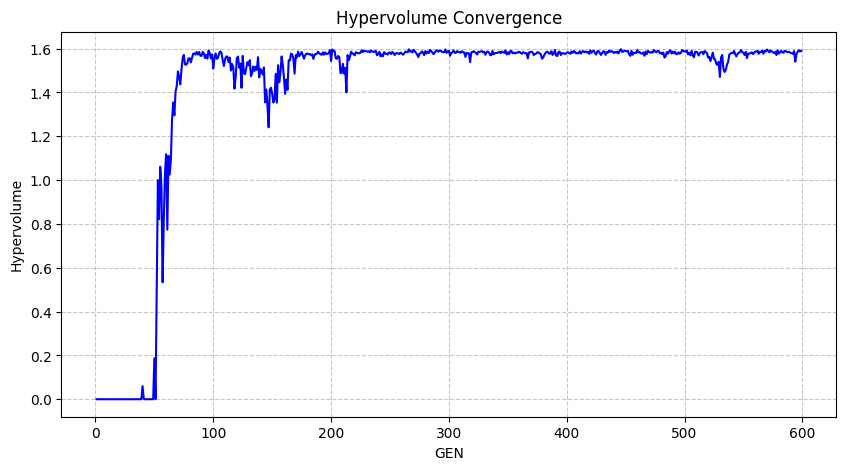

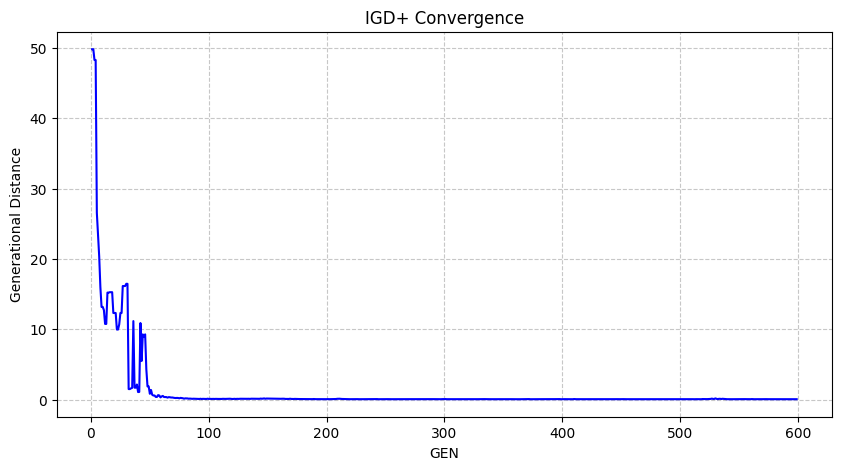

In [11]:
import matplotlib.pyplot as plt


for ind in pop:
   print(ind)

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()